In [1]:
here::i_am('code/model.ipynb')
library(dplyr)
library(tidyr)
library(expm)
library(here)
library(ggplot2)
devtools::load_all('~/Code/R/ktools')

here() starts at /scratch/fuchs/fias/knguyen/MultistageSurv




Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘expm’


The following object is masked from ‘package:Matrix’:

    expm


ℹ Loading ktools
ℹ Re-compiling ktools (debug build)



── R CMD INSTALL ───────────────────────────────────────────────────────────────
* installing *source* package ‘ktools’ ...
** using staged installation
* DONE (ktools)


Warning message in system("unar -v", intern = FALSE):
“error in running command”


In [2]:
options(
    ggplot2.discrete.colour=ktools:::okabe,
    ggplot2.discrete.fill=ktools:::okabe
)

okcol = c(
    base03 = "#002d38",
    base02 = "#093946",
    base01 = "#5b7279",
    base00 = "#657377",
    base0 = "#98a8a8",
    base1 = "#8faaab",
    base2 = "#f1e9d2",
    base3 = "#fbf7ef",
    yellow = "#ac8300",
    orange = "#d56500",
    red = "#f23749",
    magenta = "#dd459d",
    violet = "#7d80d1",
    blue = "#2b90d8",
    cyan = "#259d94",
    green = "#819500")
k.theme <- theme_light() +
    theme(
        panel.grid = element_blank(),
        panel.background = element_rect(fill = okcol['base3']),
        # panel.grid.minor = element_blank(),
        # panel.grid.major = element_blank(),
        strip.background = element_rect("white"),
        strip.text = element_text(color = "grey20", hjust = 0),
        text = element_text(size = 11, family = 'Open Sans')
    )



## Fitting

Data format with states and transition ages

In [3]:
vroom::vroom(here("data/new_d.csv"), col_select = -1, show_col_types = F) %>% 
    mutate(
        cid = as_numeric(cc) - 1, 
        A = case_when(A == 'V' ~ 0, A == "X" ~ 1, A == "M" ~ 2, A == 'S' ~ 3, A == "D" ~ 4, A == "W" ~ 5, A == "R" ~ 6),
        Z = case_when(Z == 'V' ~ 0, Z == "X" ~ 1, Z == "M" ~ 2, Z == 'S' ~ 3, Z == "D" ~ 4, Z == "W" ~ 5, Z == "R" ~ 6),
        across(where(is.numeric), as.integer)
        ) %>% 
    allot(d)
head(d)

New names:
• `` -> `...1`


cc,sex,A,Z,start,end,n,cid
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
AO,female,2,4,12,50,1,0
AO,female,2,4,13,40,1,0
AO,female,2,4,14,20,1,0
AO,female,2,4,14,41,1,0
AO,female,2,4,15,18,1,0
AO,female,2,4,15,24,2,0


Initial parameters and prior

In [4]:
data <- list()
data$prior_base <- c(0, 1) # log normal mean and sd
# data$prior_base <- c(log(0.001), 0.1) # log normal mean and sd
data$prior_t <- c(0, 0.01) # mean and sd

data$n_age <- max(d$start) + 1 # age ZERO to 60

N_PAR = 7

init <- list(
    intercepts = rnorm(N_PAR, data$prior_base[1], data$prior_base[2]), 
    pacf_vec = rep(c(1, 0), N_PAR),
    # age_sm = rnorm(N_PAR * data$n_age, 0, 0.001)
    age_sm = rep(0, N_PAR * data$n_age)
)

Need to install TMB from source (`remotes`)

In [5]:
library('TMB')
unlink(here('code/model.so'))
TMB::compile(here("code/model.cpp"))

using C++ compiler: ‘x86_64-conda-linux-gnu-c++ (Anaconda gcc) 11.2.0’



[1] 0

In [6]:
base::dyn.load(TMB::dynlib(here("code/model")))
# invisible(TMB::config(tape.parallel = 0, DLL = "model"))
# TMB::openmp(4)

Fitting country by country

In [7]:
cc <- unique(d$cc)
cc

[1] "AO" "BF" "BJ" "BU" "CD" "CG" "CI" "CM" "ET" "GA" "GH" "GM" "GN" "KE" "KM"
[16] "LB" "LS" "MD" "ML" "MR" "MW" "MZ" "NG" "NI" "NM" "RW" "SL" "SN" "ST" "SZ"
[31] "TD" "TG" "TZ" "UG" "ZA" "ZM" "ZW"

## TEst run one

In [8]:
tdt <- filter(d, cc == 'AO', sex == 'male') %>%
    select(A, Z, start, end, n) %>%
    as.list()
data <- modifyList(data, tdt)

In [9]:
obj <- TMB::MakeADFun(data, init, DLL = "model", silent = TRUE)

In [10]:
fit <- nlminb(obj$par, obj$fn, obj$gr, control = list(trace = 0, maxit = 500))

In [11]:
obj$report() %>% str()

List of 3
 $ pacf_vec  : num [1:14] 3.3809 0.0556 5.6614 -3.2187 6.8348 ...
 $ intercepts: num [1:7] -3.34 -5.51 -2.68 -3.88 -6.31 ...
 $ age_sm    : num [1:462] -3.77 -3.83 -3.85 -3.85 -3.83 ...


In [12]:
sm_age <- tibble(
    sm = obj$report(obj$env$last.par.best)$age_sm, 
    age = rep(0:65, 7), 
    grp = rep(LETTERS[1:7], each = 66)
    )
es_itc <- tibble(
    itc = obj$report(obj$env$last.par.best)$intercepts, 
    grp = LETTERS[1:7]
    )


In [13]:
eta_mat <- 
    sm_age %>% left_join(es_itc) %>% 
    mutate(eta = exp(itc + sm))  %>% 
    select(age, grp, eta)  %>% 
    pivot_wider(names_from = grp, values_from = eta)  %>% 
    select(-age) %>% 
    as.matrix

Joining with `by = join_by(grp)`


In [14]:
PQ <- function(pars) {
    P <- Q <- matrix(0, 7, 7)
    Q[1, 2] = pars[1]
    Q[1, 3] = pars[2]
    Q[2, 3] = pars[3]
    Q[3, 4:6] = pars[4:6]
    Q[4:6, 7] = pars[6]
    Q[7, 4:6] = pars[7]
    for(i in 1:7) Q[i,i] = -sum(Q[i, ])
    P = expm::expm(Q)
    list(P=P, Q=Q)
}

In [15]:
PQages <- napply(1:nrow(eta_mat), function(x) PQ(eta_mat[x, ]))

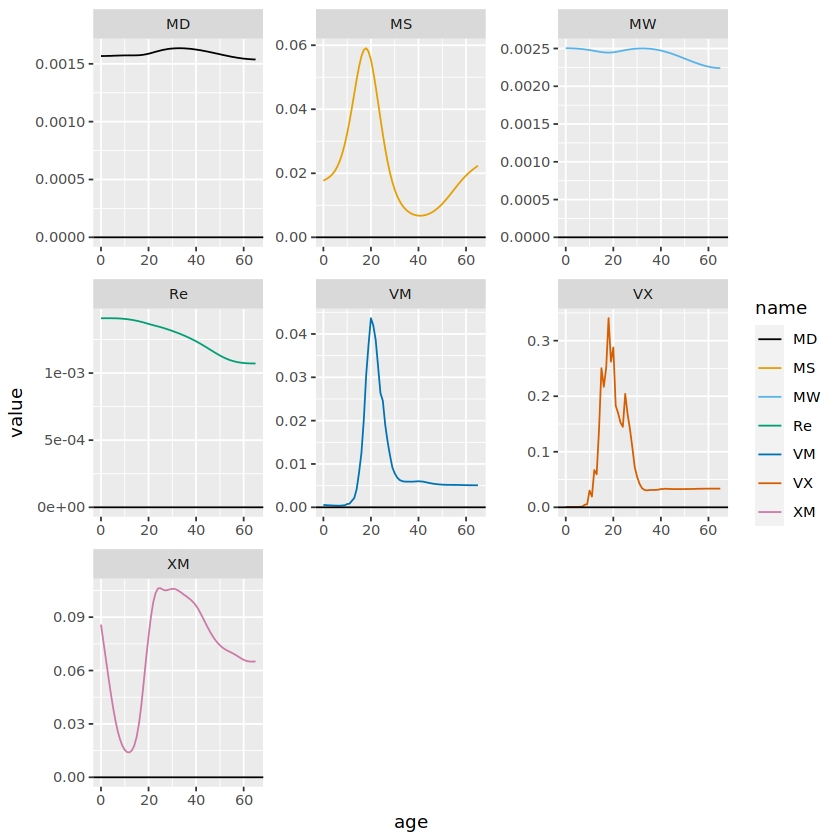

In [16]:
purrr::map_dfr(PQages, function(x) {
    tibble(
        # VV = x$P[1,1],
        VX = x$P[1,2],
        VM = x$P[1,3],
        # XX = x$P[2,2],
        XM = x$P[2,3],
        # MM = x$P[3,3],
        MS = x$P[3,4],
        MD = x$P[3,5],
        MW = x$P[3,6],
        Re = x$P[4,7],
    )}) %>% 
    mutate(age = 0:65) %>% 
    pivot_longer(-age) %>% 
    ggplot(aes(age, value, color = name)) + geom_line() +
    facet_wrap(~name, scales = 'free') +
    geom_hline(yintercept = 0)

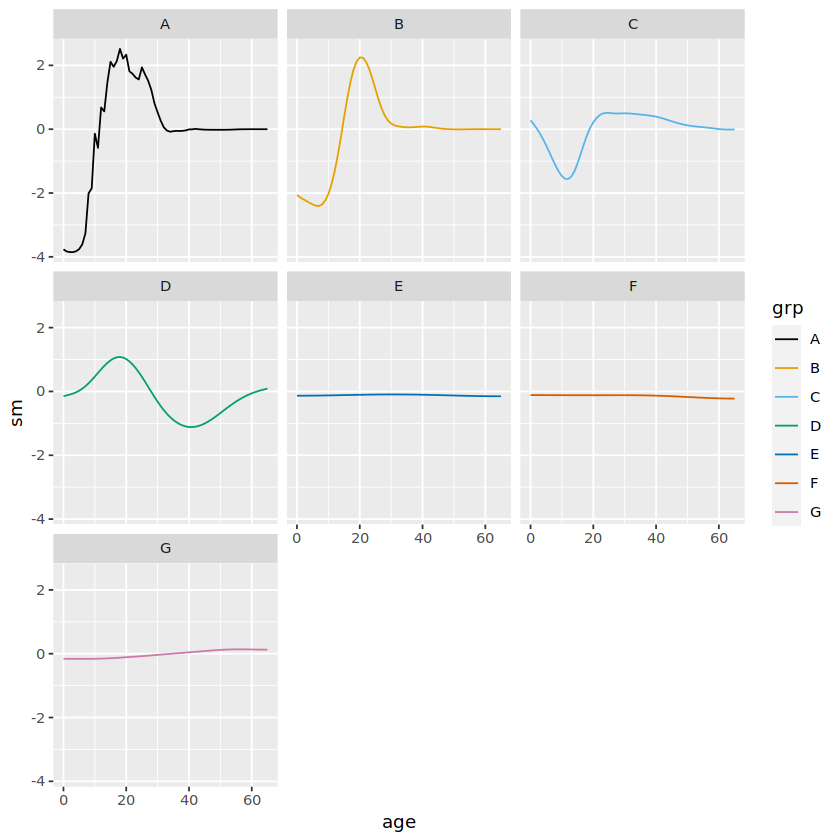

In [17]:
tibble(
    sm = obj$report(obj$env$last.par.best)$age_sm, 
    age = rep(0:65, 7), 
    grp = rep(LETTERS[1:7], each = 66)
    ) %>% 
    ggplot(aes(age, sm, color = grp)) + geom_line() + facet_wrap(~grp)

## run all

In [18]:
unlink(here('fitted'),force = T,recursive = T)

In [19]:
dir.create(here('fitted'), F)

for (k in cc) {
    for (s in char(male, female)) {
        cat(k, s, "\n")
        tdt <- filter(d, cc == k, sex == s) %>%
            select(A, Z, start, end, n) %>%
            as.list()
        data <- modifyList(data, tdt)
        t0 <- Sys.time()
        obj <- TMB::MakeADFun(data, init, DLL = "model", silent = TRUE)
        fit <- nlminb(obj$par, obj$fn, obj$gr, control = list(trace = 0, maxit = 500))
        rp <- obj$report(obj$env$last.par.best)
        save <- modifyList(fit, rp)
        save$runtime <- Sys.time() - t0
        saveRDS(save, here("fitted", paste0(k, s, ".rds")))
    }
}

AO male 
AO female 
BF male 
BF female 
BJ male 
BJ female 
BU male 
BU female 
CD male 
CD female 
CG male 
CG female 
CI male 
CI female 
CM male 
CM female 
ET male 
ET female 
GA male 
GA female 
GH male 
GH female 
GM male 
GM female 
GN male 
GN female 
KE male 
KE female 
KM male 
KM female 
LB male 
LB female 
LS male 
LS female 
MD male 
MD female 
ML male 
ML female 
MR male 
MR female 
MW male 
MW female 
MZ male 
MZ female 
NG male 
NG female 
NI male 
NI female 
NM male 
NM female 
RW male 
RW female 
SL male 
SL female 
SN male 
SN female 
ST male 
ST female 
SZ male 
SZ female 
TD male 
TD female 
TG male 
TG female 
TZ male 
TZ female 
UG male 
UG female 
ZA male 
ZA female 
ZM male 
ZM female 
ZW male 
ZW female 


In [20]:
list.files(here('fitted')) 

[1] "AOfemale.rds" "AOmale.rds"   "BFfemale.rds" "BFmale.rds"   "BJfemale.rds"
 [6] "BJmale.rds"   "BUfemale.rds" "BUmale.rds"   "CDfemale.rds" "CDmale.rds"  
[11] "CGfemale.rds" "CGmale.rds"   "CIfemale.rds" "CImale.rds"   "CMfemale.rds"
[16] "CMmale.rds"   "ETfemale.rds" "ETmale.rds"   "GAfemale.rds" "GAmale.rds"  
[21] "GHfemale.rds" "GHmale.rds"   "GMfemale.rds" "GMmale.rds"   "GNfemale.rds"
[26] "GNmale.rds"   "KEfemale.rds" "KEmale.rds"   "KMfemale.rds" "KMmale.rds"  
[31] "LBfemale.rds" "LBmale.rds"   "LSfemale.rds" "LSmale.rds"   "MDfemale.rds"
[36] "MDmale.rds"   "MLfemale.rds" "MLmale.rds"   "MRfemale.rds" "MRmale.rds"  
[41] "MWfemale.rds" "MWmale.rds"   "MZfemale.rds" "MZmale.rds"   "NGfemale.rds"
[46] "NGmale.rds"   "NIfemale.rds" "NImale.rds"   "NMfemale.rds" "NMmale.rds"  
[51] "RWfemale.rds" "RWmale.rds"   "SLfemale.rds" "SLmale.rds"   "SNfemale.rds"
[56] "SNmale.rds"   "STfemale.rds" "STmale.rds"   "SZfemale.rds" "SZmale.rds"  
[61] "TDfemale.rds" "TDmale.rds"   "TGfemale.rds" "TGmale.rds"   "TZfemale.rds"
[66] "TZmale.rds"   "UGfemale.rds" "UGmale.rds"   "ZAfemale.rds" "ZAmale.rds"  
[71] "ZMfemale.rds" "ZMmale.rds"   "ZWfemale.rds" "ZWmale.rds"

## Post fitting

Extract meta data

In [21]:
iso2 <- list.files(here('fitted')) %>% substr(1, 2)
sex <- list.files(here('fitted')) %>% substr(3, 3)

Intercept and age coefficients

In [30]:
betas <- 
list.files(here('fitted'), full.names = T) %>%
purrr::map_dfr(
    function(x) {
        tmp_ <- readRDS(x)
        sm_age <- tibble(
            sm = tmp_$age_sm, 
            age = rep(0:65, 7), 
            grp = rep(LETTERS[1:7], each = 66)
            )
        es_itc <- tibble(
            itc = tmp_$intercepts, 
            grp = LETTERS[1:7]
            )
        eta_mat <- sm_age %>% 
            left_join(es_itc, 'grp') %>% 
            mutate(eta = exp(itc + sm))  %>% 
            select(age, grp, eta)  %>% 
            pivot_wider(names_from = grp, values_from = eta) 
        eta_mat
    }, 
    .id = 'src'
)

In [32]:
betas %>% mutate(
    src = as.numeric(src),
    iso = iso2[src],
    sex = sex[src]
    )

src,age,A,B,C,D,E,F,G,iso,sex
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,0,0.0002628336,0.0003400408,0.07059235,0.013897546,0.0012001027,0.006341902,0.2756200,AO,f
1,1,0.0002352314,0.0002569243,0.06068811,0.014939862,0.0011962830,0.006588436,0.2623443,AO,f
1,2,0.0002229877,0.0002094107,0.05186491,0.016132390,0.0011906743,0.006861431,0.2490397,AO,f
1,3,0.0002211514,0.0001884499,0.04451353,0.017510389,0.0011834447,0.007165743,0.2358776,AO,f
1,4,0.0002248405,0.0001912915,0.03882890,0.019115626,0.0011744935,0.007496929,0.2230531,AO,f
1,5,0.0002366892,0.0002220996,0.03482703,0.020996904,0.0011642229,0.007856214,0.2106803,AO,f
1,6,0.0003138689,0.0002960475,0.03244184,0.023185567,0.0011527234,0.008234963,0.1988683,AO,f
1,7,0.0004204128,0.0004502741,0.03162781,0.025714879,0.0011407294,0.008626752,0.1876340,AO,f
1,8,0.0187557770,0.0007707551,0.03243335,0.028580078,0.0011280126,0.009017664,0.1769933,AO,f


Convert to P matrix

In [17]:
estP <- map_dfr(seq_along(betas), function(z) {
    eta <- exp(modelmatrix %*% betas[[z]])
    PQages <- napply(1:nrow(eta), function(x) PQ(eta[x, ]))
    map_dfr(PQages, function(x) {
        tibble(
            VV = x$P[1,1],
            VX = x$P[1,2],
            VM = x$P[1,3],
            XX = x$P[2,2],
            XM = x$P[2,3],
            MM = x$P[3,3],
            MS = x$P[3,4],
            MD = x$P[3,5],
            MW = x$P[3,6],
            Re = x$P[4,7],
        )}) %>% 
        mutate(age = 0:65, cc = iso2[z], sex = sex[z])
})

ERROR: Error in map_dfr(seq_along(betas), function(z) {: could not find function "map_dfr"


In [ ]:
estP %>% str()

tibble [4,884 × 13] (S3: tbl_df/tbl/data.frame)
 $ VV : num [1:4884] 0.991 0.989 0.987 0.985 0.983 ...
 $ VX : num [1:4884] 0.00718 0.00835 0.00972 0.01131 0.01315 ...
 $ VM : num [1:4884] 0.00223 0.00262 0.00307 0.0036 0.00422 ...
 $ XX : num [1:4884] 0.927 0.927 0.926 0.925 0.924 ...
 $ XM : num [1:4884] 0.0716 0.0725 0.0734 0.0743 0.0753 ...
 $ MM : num [1:4884] 0.973 0.973 0.974 0.974 0.974 ...
 $ MS : num [1:4884] 0.0231 0.0228 0.0226 0.0223 0.0221 ...
 $ MD : num [1:4884] 0.00111 0.0011 0.00109 0.00107 0.00106 ...
 $ MW : num [1:4884] 0.00256 0.0026 0.00264 0.00269 0.00273 ...
 $ Re : num [1:4884] 0.00258 0.00262 0.00266 0.00269 0.00273 ...
 $ age: int [1:4884] 0 1 2 3 4 5 6 7 8 9 ...
 $ cc : chr [1:4884] "AO" "AO" "AO" "AO" ...
 $ sex: chr [1:4884] "f" "f" "f" "f" ...


In [ ]:
estP %>%
    filter(!(sex == 'f' & age > 49)) %>% # not in data
    mutate(
        region = countrycode::countrycode(cc, 'dhs', 'un.regionsub.name'),
        cc = countrycode::countrycode(cc, 'dhs', 'country.name'),
        debut = VX, 
        married = (VX * XM) + VM,
        divorce = MD, 
        widowed = MW, 
        separated = MS, 
        remarried = Re, 
    ) %>% 
    allot(estPP)

## Estimated transition

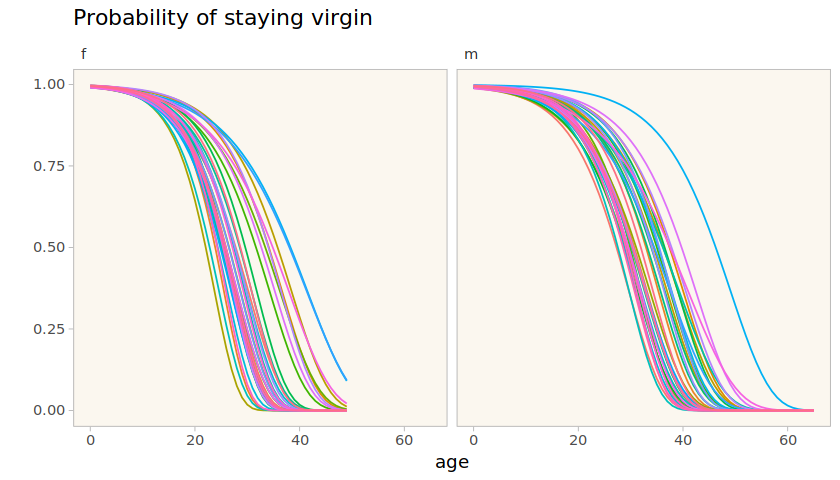

In [ ]:
sizing(7,4)
estPP %>% 
    ggplot(aes(age, VV, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of staying virgin", y = '', linetype = "Transition")

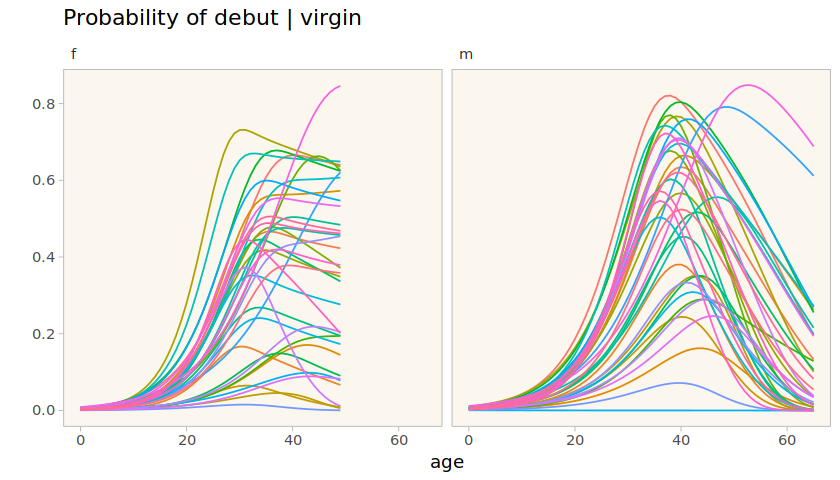

In [ ]:
estPP %>% 
    ggplot(aes(age, VX, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of debut | virgin", y = '', linetype = "Transition")

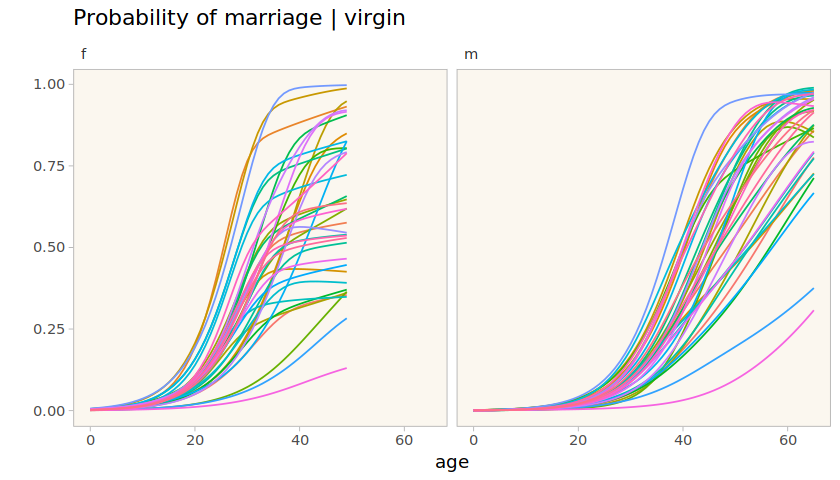

In [ ]:
estPP %>% 
    ggplot(aes(age, VM, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of marriage | virgin", y = '', linetype = "Transition")

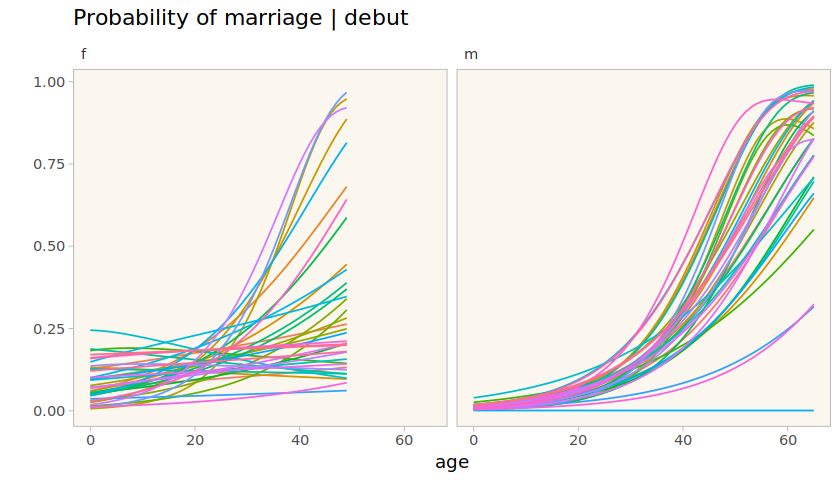

In [ ]:
estPP %>% 
    ggplot(aes(age, XM, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of marriage | debut", y = '', linetype = "Transition")

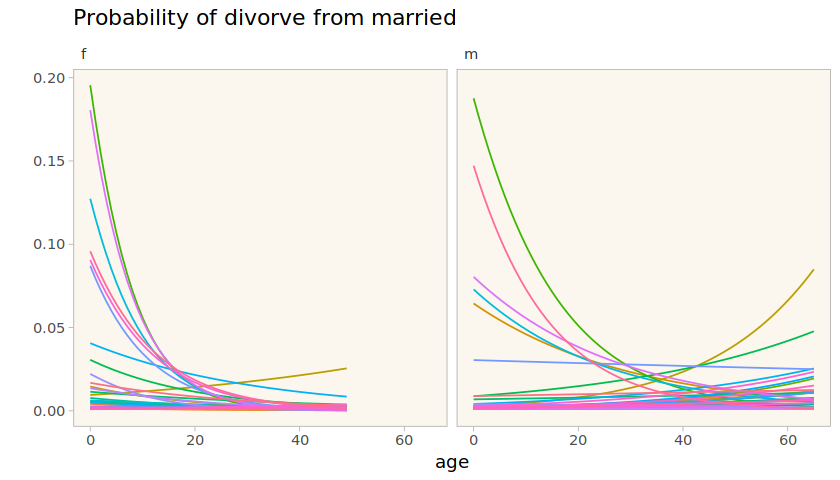

In [ ]:
estPP %>% 
    ggplot(aes(age, MD, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of divorve from married", y = '', linetype = "Transition")

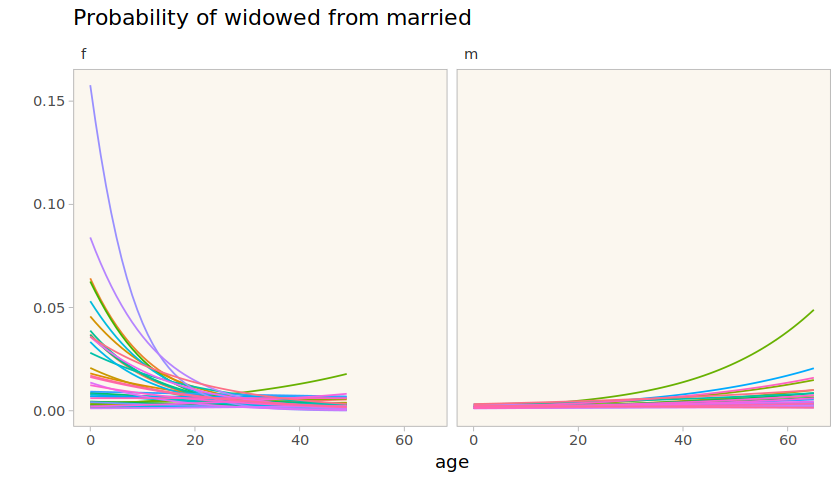

In [ ]:
estPP %>% 
    ggplot(aes(age, MW, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of widowed from married", y = '', linetype = "Transition")

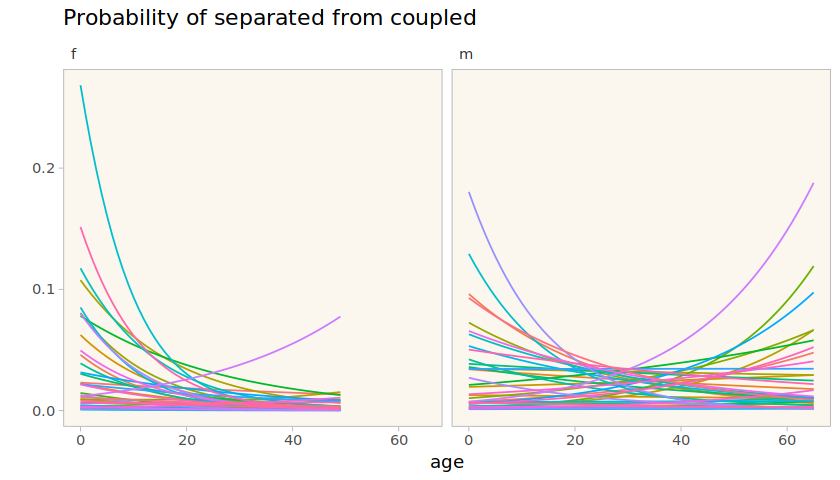

In [ ]:
estPP %>% 
    ggplot(aes(age, MS, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex) +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of separated from coupled", y = '', linetype = "Transition")

In [ ]:
str(estPP)

tibble [4,292 × 20] (S3: tbl_df/tbl/data.frame)
 $ VV       : num [1:4292] 0.991 0.989 0.987 0.985 0.983 ...
 $ VX       : num [1:4292] 0.00718 0.00835 0.00972 0.01131 0.01315 ...
 $ VM       : num [1:4292] 0.00223 0.00262 0.00307 0.0036 0.00422 ...
 $ XX       : num [1:4292] 0.927 0.927 0.926 0.925 0.924 ...
 $ XM       : num [1:4292] 0.0716 0.0725 0.0734 0.0743 0.0753 ...
 $ MM       : num [1:4292] 0.973 0.973 0.974 0.974 0.974 ...
 $ MS       : num [1:4292] 0.0231 0.0228 0.0226 0.0223 0.0221 ...
 $ MD       : num [1:4292] 0.00111 0.0011 0.00109 0.00107 0.00106 ...
 $ MW       : num [1:4292] 0.00256 0.0026 0.00264 0.00269 0.00273 ...
 $ Re       : num [1:4292] 0.00258 0.00262 0.00266 0.00269 0.00273 ...
 $ age      : int [1:4292] 0 1 2 3 4 5 6 7 8 9 ...
 $ cc       : chr [1:4292] "Angola" "Angola" "Angola" "Angola" ...
 $ sex      : chr [1:4292] "f" "f" "f" "f" ...
 $ region   : chr [1:4292] "Sub-Saharan Africa" "Sub-Saharan Africa" "Sub-Saharan Africa" "Sub-Saharan Africa" ...
 $ de

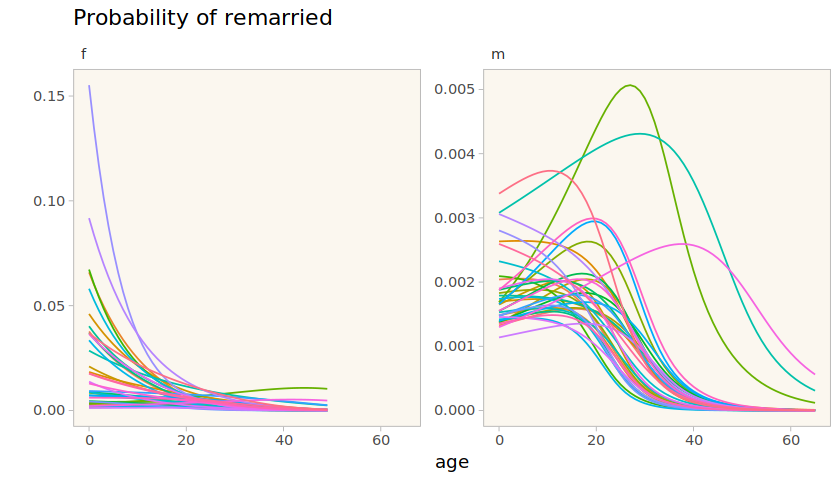

In [ ]:
estPP %>% 
    ggplot(aes(age, Re, color = cc)) + 
    geom_line() + 
    facet_wrap(~sex, scales = 'free_y') +
    ktheme +
    guides(color = 'none') +
    labs(title = "Probability of remarried", y = '', linetype = "Transition")